In [1]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 48.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=12470de8f53ade775eef563591d12a092f339e7fe042881ebd7c8264bfc29b40
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [2]:
import torch
import torchvision
from torchvision import models
from torch.utils.data import Subset
import numpy as np
import matplotlib.pyplot as plt
import cv2

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/MyDrive')

import plot_utils
import utils
from explanations import RISE

Mounted at /content/drive


In [3]:
# Load pretrained ResNet-50 (ImageNet weights)
weights = models.ResNet50_Weights.DEFAULT
model = models.resnet50(weights=weights)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Set to evaluation mode
model.eval()

# Preprocess the image as described in the pytorch documentation
preprocess = weights.transforms()

# Load Pascal VOC dataset
dataset = torchvision.datasets.VOCDetection(
    root="./data",
    year="2012",
    image_set="val",
    download=True,
)
print(len(dataset))
np.random.seed(64)

indices = np.random.choice(len(dataset), 4, replace=False)
dataset_sub = Subset(dataset, indices)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 89.2MB/s]
100%|██████████| 2.00G/2.00G [01:32<00:00, 21.7MB/s]


5823


In [4]:
explainer = RISE(model, (224, 224), 1, device)
explainer.generate_masks(N=8000, s=7, p1=0.5) # N=8000

Generating filters: 100%|██████████| 8000/8000 [00:23<00:00, 337.00it/s]


Pekinese: 42.27%
Top 5 -> [Pekinese: 42.27%, bathtub: 1.41%, tub: 1.32%, Brabancon griffon: 0.82%, pug: 0.56%]
window shade: 15.13%
Top 5 -> [window shade: 15.13%, hourglass: 9.63%, window screen: 3.15%, switch: 2.94%, bannister: 2.88%]
goblet: 6.60%
Top 5 -> [goblet: 6.60%, eggnog: 4.78%, perfume: 3.91%, brassiere: 2.30%, cup: 2.20%]
minibus: 16.96%
Top 5 -> [minibus: 16.96%, trolleybus: 3.42%, streetcar: 3.08%, triumphal arch: 1.81%, palace: 1.20%]


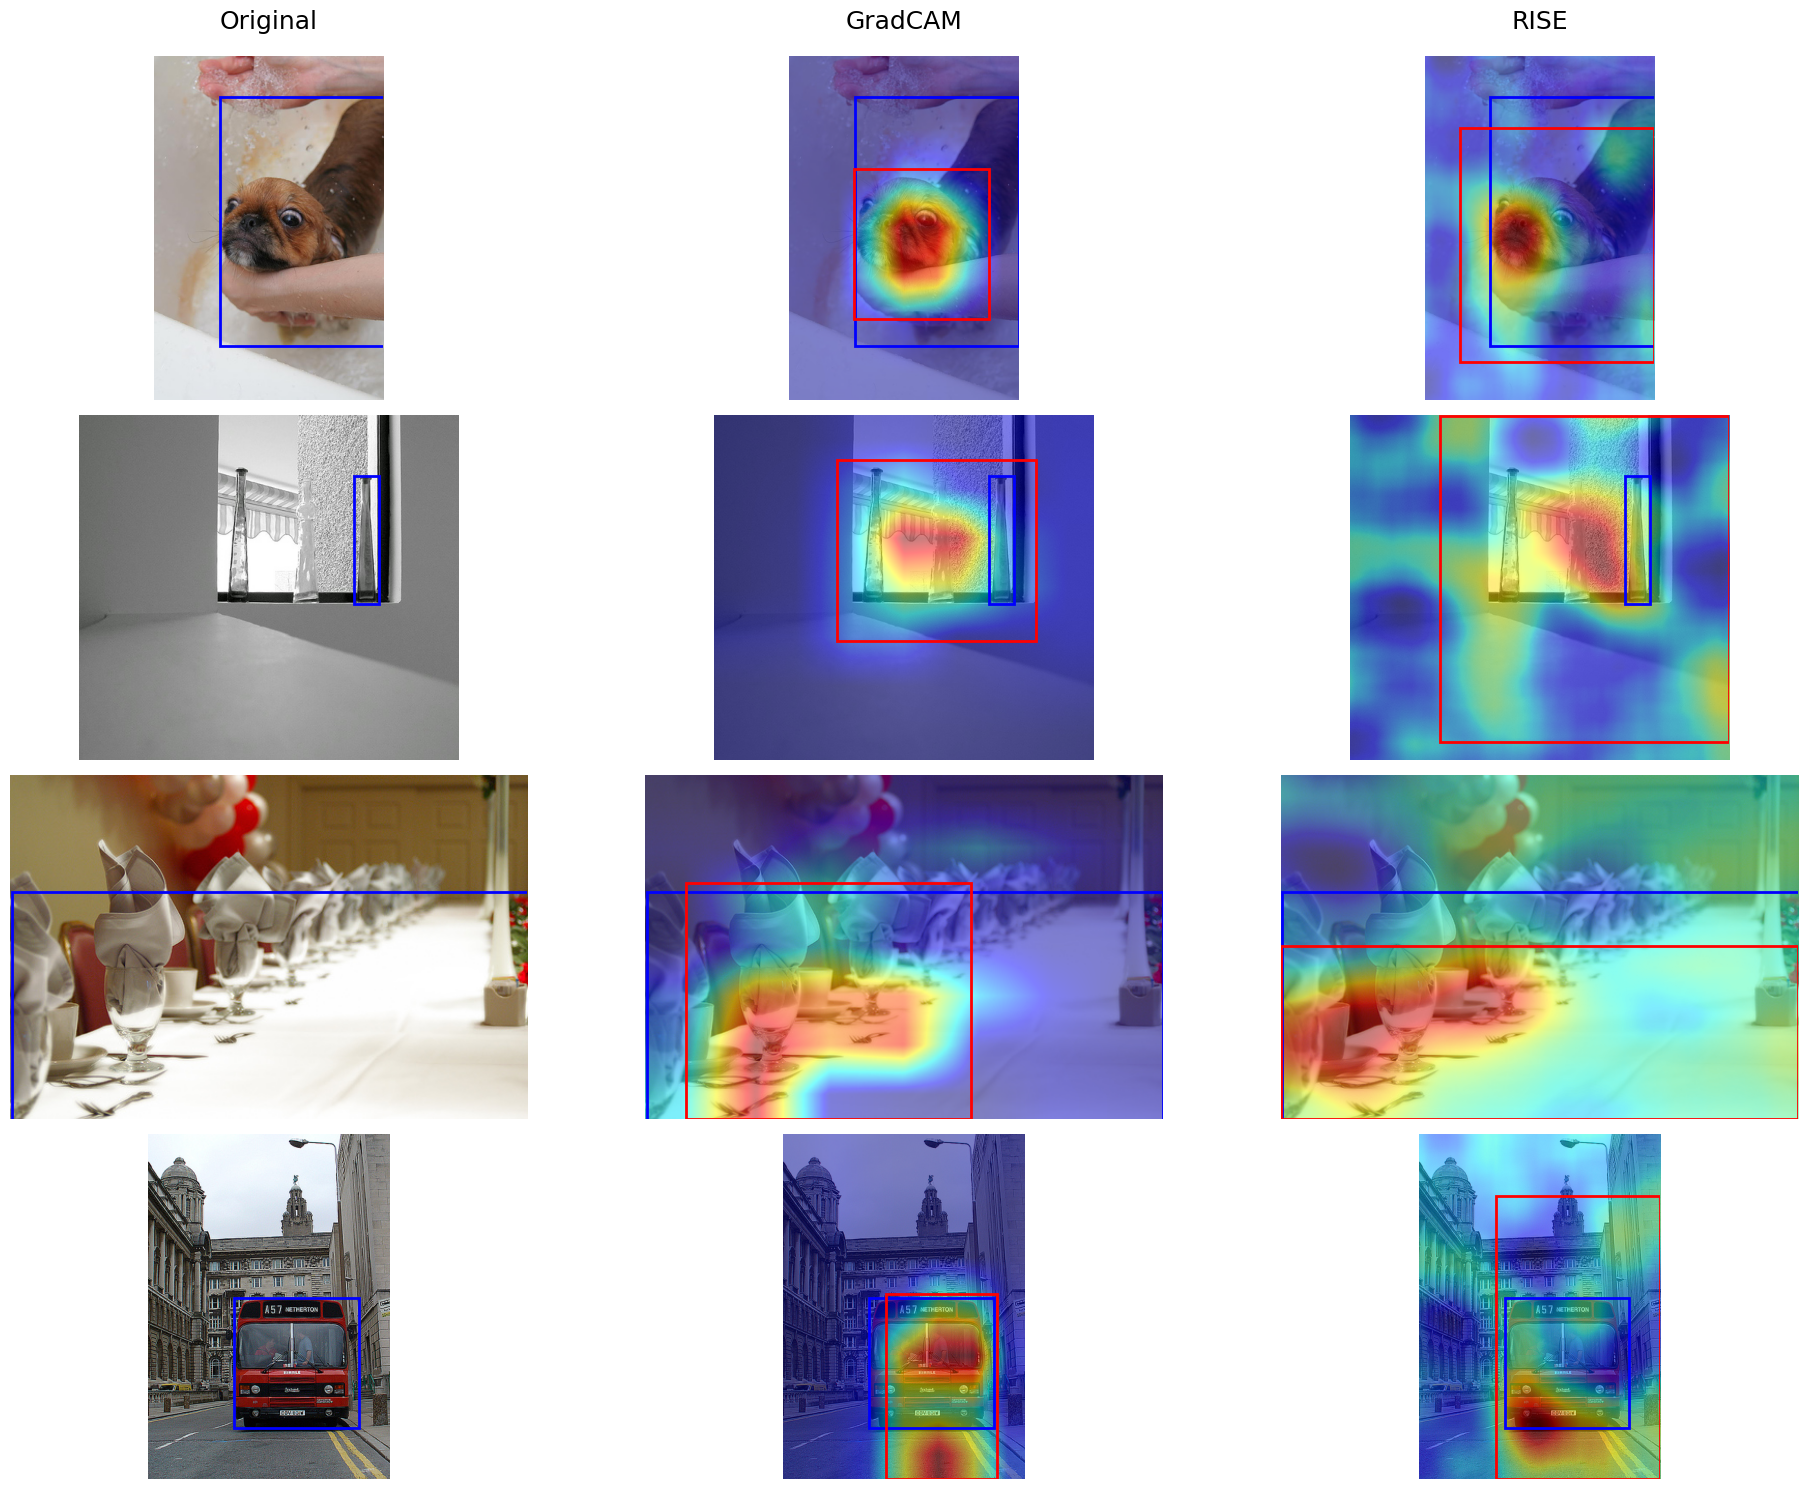

In [5]:
IoUs_grad_cam = []
IoUs_rise = []
faithfulness_scores_grad_cam = []
faithfulness_scores_rise = []
masked_images_grad_cam = []
masked_images_rise = []

is_true = True # plot results
target_layers = [model.layer4[-1]]

if is_true:
  f, ax = plt.subplots(nrows=4, ncols=3, figsize=(20, 15))

  col_titles = ["Original", "GradCAM", "RISE"]

  # column headers
  for j in range(3):
    ax[0][j].set_title(col_titles[j], fontsize=18, pad=20)

for i in range(len(dataset_sub)):
    ## Original Image
    image, target = dataset_sub[i]

    prediction, class_id, score, category_name = utils.make_prediction(
        image=image,
        model=model,
        preprocess=preprocess,
        weights=weights,
        device=device
        )

    utils.return_prediction(prediction, score, category_name, weights)

    area_of_interest_raw_image = utils.get_area_of_interest(target)  # bounding box -> ground thruth

    ## GRAD-CAM
    with GradCAM(model=model, target_layers=target_layers) as cam:
        grayscale_cams = cam(input_tensor = preprocess(image).unsqueeze(0).to(device),
                             targets = [ClassifierOutputTarget(class_id)]
                             )
        grayscale_cams = grayscale_cams[0, :]

    rgb_img = np.array(image).astype(np.float32)/255.0
    grayscale_cam = cv2.resize(grayscale_cams,(rgb_img.shape[1],rgb_img.shape[0]))
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    area_of_interest_grad_cam = utils.get_area_of_interest(target)
    top_20_grad_cam = utils.get_top_20(grayscale_cam)
    area_of_importance_grad_cam = utils.get_area_of_importance(top_20_grad_cam) # bounding box -> importance

    ## RISE
    img = preprocess(image).unsqueeze(0).to(device)
    with torch.no_grad():
        saliency = explainer(img).cpu().numpy()
        p, c = torch.topk(model(img), k=1)
        p, c = p[0], c[0]

    sal = saliency[c[0]]

    # rgb_img = np.array(image).astype(np.float32) / 255.0
    sal = cv2.resize(sal, (rgb_img.shape[1], rgb_img.shape[0]))

    area_of_interest_rise = utils.get_area_of_interest(target)
    top_20_rise = utils.get_top_20(sal)
    area_of_importance_rise = utils.get_area_of_importance(top_20_rise) # bounding box -> importance

    ## Intersection over union + faithfulness
    IoU_grad_cam = utils.get_IoU(area_of_interest_grad_cam.get_bbox(),
                        area_of_importance_grad_cam.get_bbox())
    IoU_rise = utils.get_IoU(area_of_interest_rise.get_bbox(),
                        area_of_importance_rise.get_bbox())

    IoUs_grad_cam.append(IoU_grad_cam)
    IoUs_rise.append(IoU_rise)

    faithfulness_grad_cam, _, _, masked_image_grad_cam = utils.compute_faithfulness(
        image=image,
        image_np=rgb_img,
        mask=top_20_grad_cam,
        class_idx=class_id,
        model=model,
        preprocess=preprocess,
        device=device
    )

    faithfulness_rise, _, _, masked_image_rise = utils.compute_faithfulness(
        image=image,
        image_np=rgb_img,
        mask=top_20_rise,
        class_idx=class_id,
        model=model,
        preprocess=preprocess,
        device=device
    )

    faithfulness_scores_grad_cam.append(faithfulness_grad_cam)
    faithfulness_scores_rise.append(faithfulness_rise)

    masked_images_grad_cam.append(masked_image_grad_cam)
    masked_images_rise.append(masked_image_rise)

    ## Plot
    if is_true:
      # ax[i][0].set_title(target['annotation']['object'][0]['name'], fontsize=16)
      ax[i][0].imshow(image)
      ax[i][0].axis('off')
      # Add the square to the axes
      ax[i][0].add_patch(area_of_interest_raw_image)

      ax[i][1].add_patch(area_of_interest_grad_cam)
      ax[i][1].add_patch(area_of_importance_grad_cam)
      # if (weights is not None) and (indices is not None):
      # ax[i][1].set_title(weights.meta["categories"][class_id], fontsize=16)
      ax[i][1].imshow(visualization)
      ax[i][1].axis('off')

      ax[i][2].add_patch(area_of_interest_rise)
      ax[i][2].add_patch(area_of_importance_rise)
      # ax[i][2].set_title(weights.meta["categories"][class_id], fontsize=12)
      ax[i][2].imshow(rgb_img)
      ax[i][2].imshow(sal, cmap='jet', alpha=0.5)
      ax[i][2].axis('off')

if is_true:
  plt.tight_layout()
  plt.show()


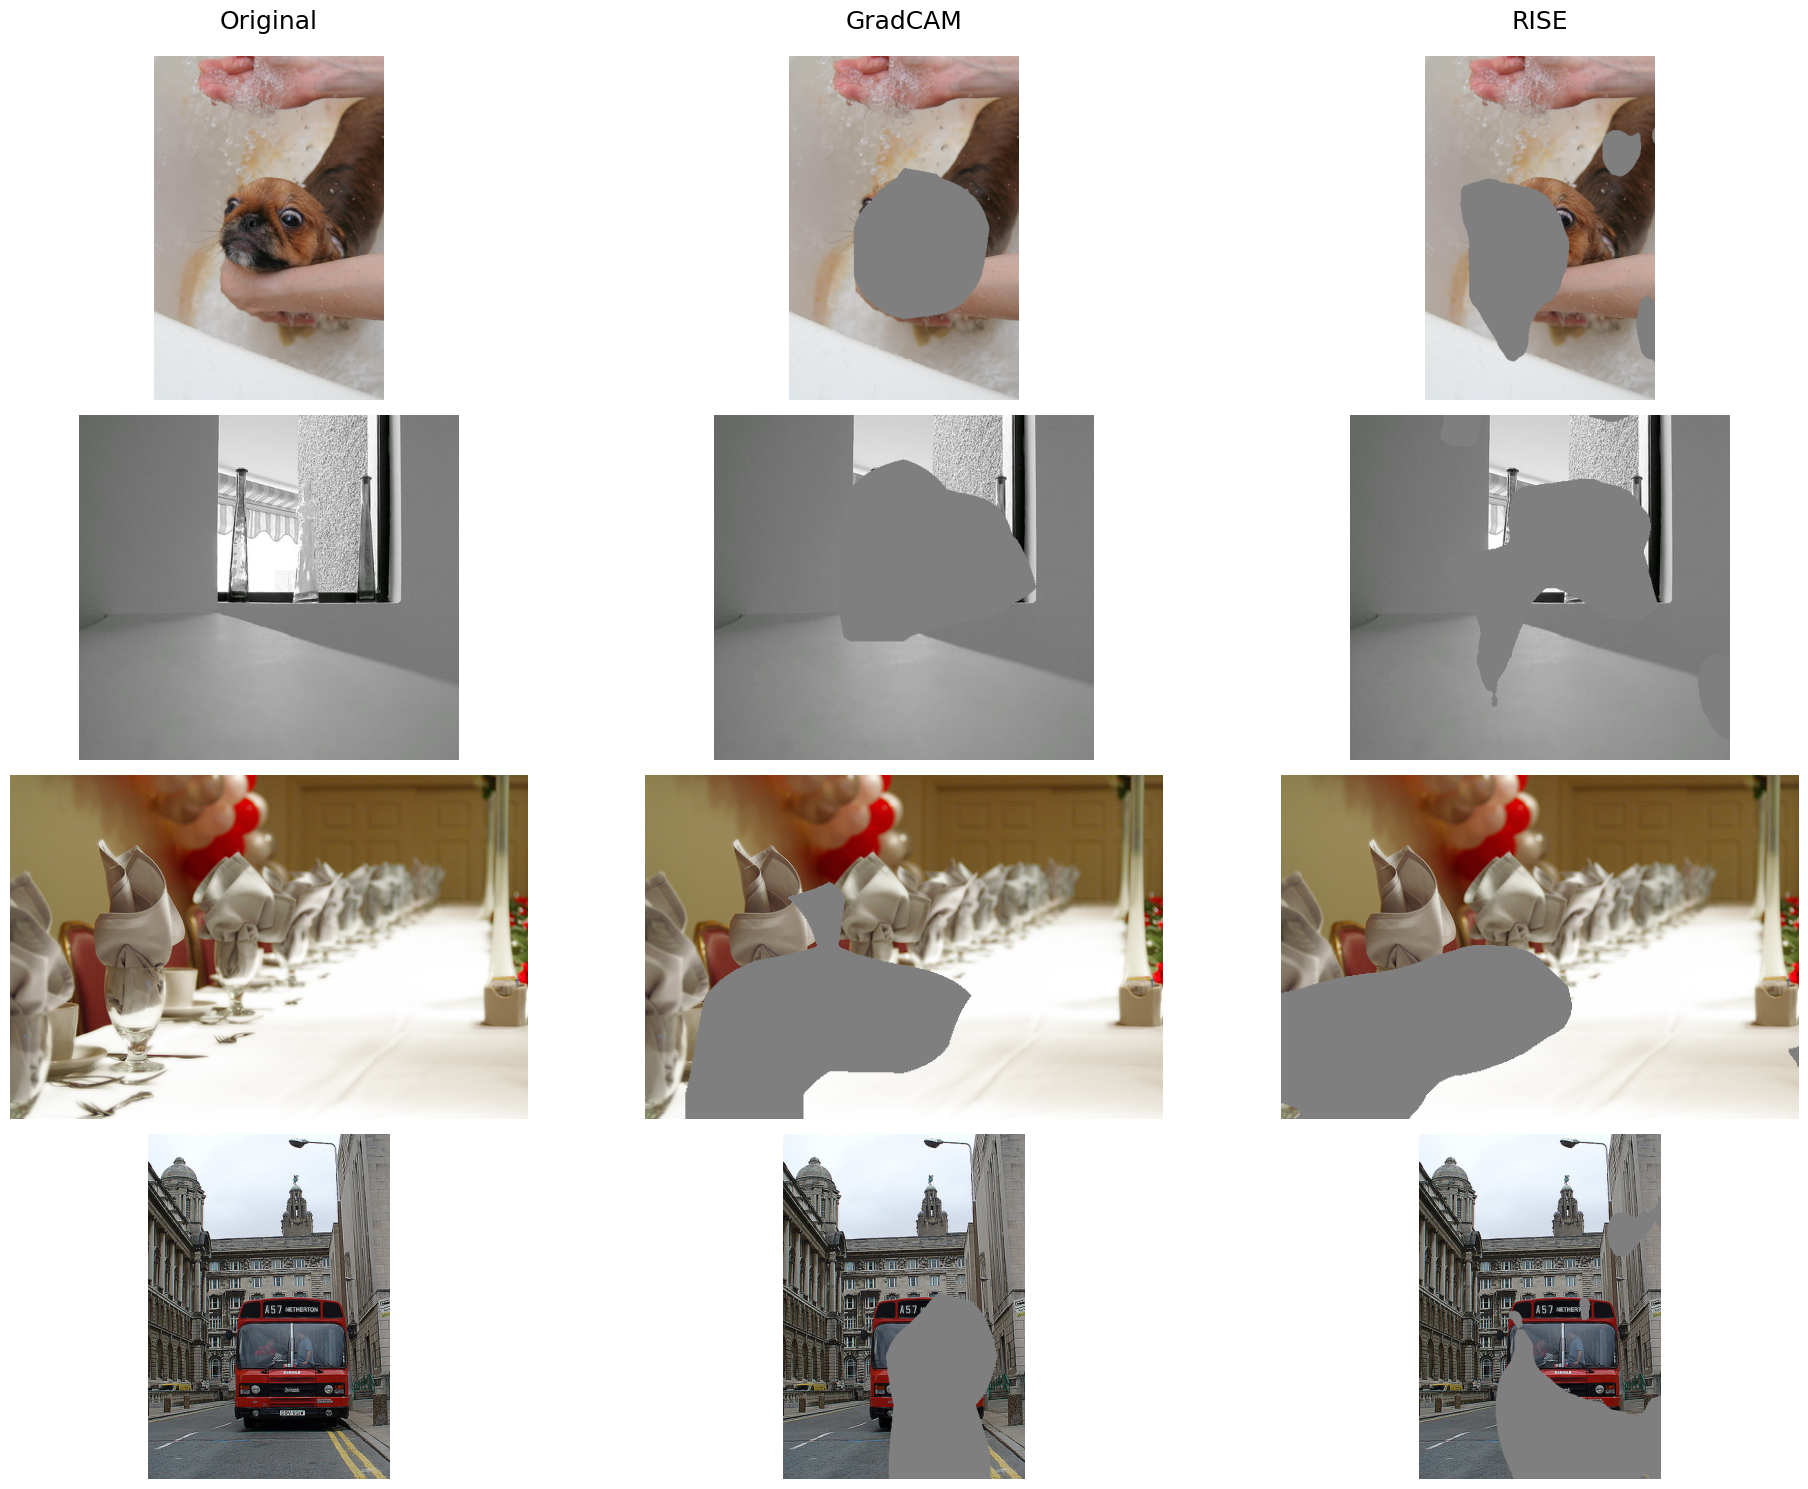

In [6]:
plot_utils.display_masked_image(dataset_sub, masked_images_grad_cam, masked_images_rise)

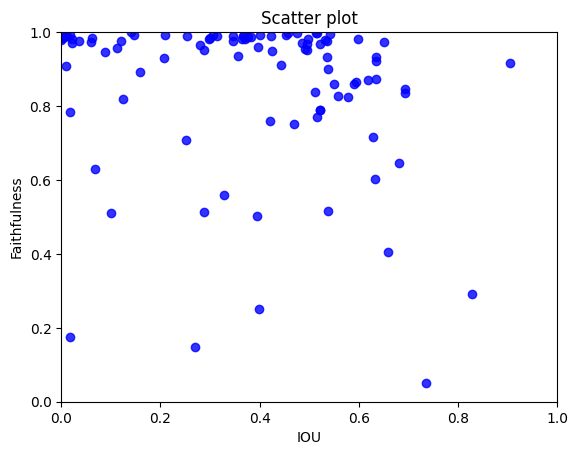

Spearman correlation: -0.2948
p-value: 0.0029


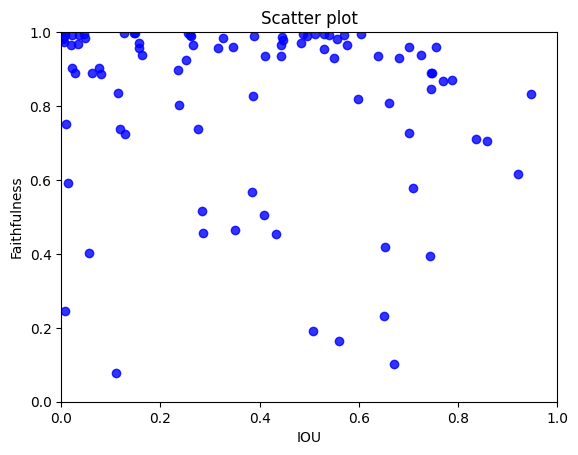

Spearman correlation: -0.2634
p-value: 0.0081


(np.float64(-0.2634263426342634), np.float64(0.00809480109152546))

In [6]:
plot_utils.scatter_plot(IoUs_grad_cam, faithfulness_scores_grad_cam)
utils.get_spearman_correlation(IoUs_grad_cam, faithfulness_scores_grad_cam)

plot_utils.scatter_plot(IoUs_rise, faithfulness_scores_rise)
utils.get_spearman_correlation(IoUs_rise, faithfulness_scores_rise)